
# Periodicity-test sensitivity explorer

This notebook simulates phases on $[0,1)$ from a mixture of uniform background and a periodic pulse, then compares the sensitivity of several periodicity / non-uniformity tests:

- Pearson $\chi^2$ test on binned phases
- KS test against Uniform$(0,1)$
- Kuiper test against Uniform$(0,1)$
- Beran-style matched test assuming a Gaussian pulse template
- Rayleigh statistic $Z_1^2$
- H-test

## Simulation model

The phase PDF is

\[
f(\phi) = p\,f_s(\phi) + (1-p), \qquad \phi \in [0,1),
\]

where:

- $p$ is the pulsed fraction / signal amplitude,
- $f_s(\phi)$ is the signal-only pulse profile,
- the background component is uniform on $[0,1)$ with density 1.

The default signal shape is a wrapped Gaussian centered at $\mu=0.25$ with width $\sigma=0.10$ in phase units.

## What this notebook does

1. Simulates one realization and plots the phase histogram together with the true model.
2. Computes all six tests on the same realization.
3. Runs Monte Carlo sensitivity studies versus pulsed fraction.
4. Builds width-vs-amplitude heat maps.
5. Shows how the $\chi^2$ test depends on the number of phase bins $K$.

All important simulation parameters can be changed in the **User controls** cell below.


In [1]:

# Imports
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Iterable, Tuple

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy import stats

TWO_PI = 2.0 * np.pi

# Make plots a bit larger and cleaner
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11


## User controls

In [2]:

@dataclass
class SimulationConfig:
    n_events: int = 600
    p: float = 0.20
    mu: float = 0.25
    sigma: float = 0.10
    pulse_shape: str = "gaussian"   # "gaussian", "top_hat", "two_peak"
    k_bins: int = 20
    h_mmax: int = 20
    seed: int = 12345

# Default configuration
cfg = SimulationConfig(
    n_events=600,
    p=0.20,
    mu=0.25,
    sigma=0.10,
    pulse_shape="gaussian",
    k_bins=20,
    h_mmax=20,
    seed=12345,
)

# Monte Carlo controls
n_trials_1d = 200          # realizations per p-value in the 1D sensitivity curve
n_trials_2d = 100          # realizations per grid point in the heat maps
p_grid = np.linspace(0.0, 0.50, 11)
sigma_grid = np.linspace(0.02, 0.20, 9)
k_grid = np.unique(np.clip(np.round(np.linspace(4, 60, 15)).astype(int), 2, None))

print(cfg)
print(f"p_grid     = {p_grid}")
print(f"sigma_grid = {sigma_grid}")
print(f"k_grid     = {k_grid}")


SimulationConfig(n_events=600, p=0.2, mu=0.25, sigma=0.1, pulse_shape='gaussian', k_bins=20, h_mmax=20, seed=12345)
p_grid     = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
sigma_grid = [0.02   0.0425 0.065  0.0875 0.11   0.1325 0.155  0.1775 0.2   ]
k_grid     = [ 4  8 12 16 20 24 28 32 36 40 44 48 52 56 60]


## Pulse-shape PDFs and simulation

In [3]:

def wrapped_gaussian_pdf(phi: np.ndarray, mu: float = 0.25, sigma: float = 0.10,
                         wrap_terms: int = 3) -> np.ndarray:
    """
    Wrapped Gaussian density on [0,1), evaluated by summing a normal PDF
    over neighboring integer phase wraps.
    """
    phi = np.asarray(phi)
    shifts = np.arange(-wrap_terms, wrap_terms + 1)
    z = phi[..., None] - mu + shifts
    norm = 1.0 / (np.sqrt(2.0 * np.pi) * sigma)
    pdf = np.sum(norm * np.exp(-0.5 * (z / sigma) ** 2), axis=-1)
    return np.maximum(pdf, 0.0)


def top_hat_pdf(phi: np.ndarray, mu: float = 0.25, width: float = 0.10) -> np.ndarray:
    """Periodic top-hat pulse profile on [0,1)."""
    phi = np.asarray(phi)
    d = ((phi - mu + 0.5) % 1.0) - 0.5
    inside = np.abs(d) <= width / 2.0
    pdf = np.zeros_like(phi, dtype=float)
    pdf[inside] = 1.0 / width
    return pdf


def two_peak_pdf(phi: np.ndarray, mu: float = 0.25, sigma: float = 0.06,
                 separation: float = 0.25) -> np.ndarray:
    """Equal mixture of two wrapped Gaussians."""
    return (
        0.5 * wrapped_gaussian_pdf(phi, mu=mu, sigma=sigma)
        + 0.5 * wrapped_gaussian_pdf(phi, mu=(mu + separation) % 1.0, sigma=sigma)
    )


PULSE_SHAPES: Dict[str, Callable[..., np.ndarray]] = {
    "gaussian": wrapped_gaussian_pdf,
    "top_hat": top_hat_pdf,
    "two_peak": two_peak_pdf,
}


def pulse_pdf(phi: np.ndarray, *, pulse_shape: str, mu: float, sigma: float) -> np.ndarray:
    """Dispatch the selected signal-only pulse PDF f_s(phi)."""
    if pulse_shape not in PULSE_SHAPES:
        raise ValueError(f"Unknown pulse_shape={pulse_shape!r}. Choose from {list(PULSE_SHAPES)}")

    if pulse_shape == "gaussian":
        return wrapped_gaussian_pdf(phi, mu=mu, sigma=sigma)
    if pulse_shape == "top_hat":
        return top_hat_pdf(phi, mu=mu, width=max(sigma, 1e-3))
    if pulse_shape == "two_peak":
        return two_peak_pdf(phi, mu=mu, sigma=max(sigma, 1e-3))
    raise RuntimeError("Unhandled pulse shape.")


def sample_phases(rng: np.random.Generator, cfg: SimulationConfig) -> np.ndarray:
    """
    Sample phases from the mixture

        f(phi) = p f_s(phi) + (1-p),   phi in [0,1)

    using direct mixture sampling.
    """
    n = cfg.n_events
    is_signal = rng.random(n) < cfg.p
    phases = rng.random(n)
    n_signal = int(np.sum(is_signal))

    if n_signal > 0:
        if cfg.pulse_shape == "gaussian":
            phases[is_signal] = np.mod(
                rng.normal(loc=cfg.mu, scale=cfg.sigma, size=n_signal), 1.0
            )
        elif cfg.pulse_shape == "top_hat":
            half = cfg.sigma / 2.0
            phases[is_signal] = np.mod(
                cfg.mu + rng.uniform(-half, half, size=n_signal), 1.0
            )
        elif cfg.pulse_shape == "two_peak":
            choose_first = rng.random(n_signal) < 0.5
            mus = np.where(choose_first, cfg.mu, (cfg.mu + 0.25) % 1.0)
            phases[is_signal] = np.mod(
                rng.normal(loc=mus, scale=cfg.sigma, size=n_signal), 1.0
            )
        else:
            raise ValueError(f"Unsupported pulse shape: {cfg.pulse_shape}")

    return np.sort(phases)


## Periodicity / non-uniformity tests

In [4]:

def chi_square_test(phases: np.ndarray, k_bins: int = 20) -> Tuple[float, float]:
    """Pearson chi-square test for uniformity on K phase bins."""
    counts, _ = np.histogram(phases, bins=np.linspace(0.0, 1.0, k_bins + 1))
    expected = np.full(k_bins, phases.size / k_bins, dtype=float)
    stat = np.sum((counts - expected) ** 2 / expected)
    pval = stats.chi2.sf(stat, df=k_bins - 1)
    return float(stat), float(pval)


def ks_test_uniform(phases: np.ndarray) -> Tuple[float, float]:
    """Two-sided KS test against Uniform(0,1)."""
    result = stats.kstest(phases, "uniform")
    return float(result.statistic), float(result.pvalue)


def _series_sum_until_small(term_fn: Callable[[int], float], tol: float = 1e-12,
                            max_terms: int = 10000) -> float:
    total = 0.0
    for j in range(1, max_terms + 1):
        term = term_fn(j)
        total += term
        if abs(term) < tol:
            break
    return total


def kuiper_qkp(lam: float) -> float:
    """Asymptotic Kuiper survival-function approximation Q_KP(lambda)."""
    if lam <= 0:
        return 1.0
    q = 2.0 * _series_sum_until_small(
        lambda j: (4.0 * (j ** 2) * (lam ** 2) - 1.0) * np.exp(-2.0 * (j ** 2) * (lam ** 2)),
        tol=1e-14,
        max_terms=100000
    )
    return float(np.clip(q, 0.0, 1.0))


def kuiper_test_uniform(phases: np.ndarray) -> Tuple[float, float]:
    """Kuiper test against Uniform(0,1)."""
    x = np.sort(phases)
    n = x.size
    i = np.arange(1, n + 1)

    d_plus = np.max(i / n - x)
    d_minus = np.max(x - (i - 1) / n)
    v = d_plus + d_minus

    lam = (np.sqrt(n) + 0.155 + 0.24 / np.sqrt(n)) * v
    pval = kuiper_qkp(lam)
    return float(v), float(pval)


def beran_score_test(phases: np.ndarray, *, mu: float = 0.25, sigma: float = 0.10,
                     grid_size: int = 4096) -> Tuple[float, float]:
    """
    Beran-style matched score test assuming a Gaussian pulse template.

    Let
        f_s(phi) = wrapped Gaussian template
        w(phi)   = f_s(phi) - 1

    Then under H0 (uniformity), E[w]=0. Use

        B = [Σ_i w(phi_i)]^2 / (n C),

    where
        C = ∫_0^1 (f_s(phi)-1)^2 dphi.

    This is approximately chi-square with 1 d.o.f. under H0.
    """
    grid = np.linspace(0.0, 1.0, grid_size, endpoint=False)
    fs_grid = wrapped_gaussian_pdf(grid, mu=mu, sigma=sigma)
    w_grid = fs_grid - 1.0
    c = np.trapz(w_grid ** 2, grid)

    fs_sample = wrapped_gaussian_pdf(phases, mu=mu, sigma=sigma)
    w_sum = np.sum(fs_sample - 1.0)

    stat = (w_sum ** 2) / (phases.size * c)
    pval = stats.chi2.sf(stat, df=1)
    return float(stat), float(pval)


def rayleigh_test(phases: np.ndarray) -> Tuple[float, float]:
    """
    Rayleigh Z1^2 test.
    Under H0, Z1^2 ~ chi-square with 2 d.o.f.
    """
    theta = TWO_PI * phases
    c = np.sum(np.cos(theta))
    s = np.sum(np.sin(theta))
    z1 = (2.0 / phases.size) * (c ** 2 + s ** 2)
    pval = np.exp(-z1 / 2.0)
    return float(z1), float(pval)


def h_test(phases: np.ndarray, mmax: int = 20) -> Tuple[float, float]:
    """
    H-test:
        H = max_{1<=m<=mmax} [ Z_m^2 - 4m + 4 ]
    with approximate tail:
        P(H > h) ≈ exp(-0.398 h)
    """
    theta = TWO_PI * phases
    n = phases.size
    ks = np.arange(1, mmax + 1)

    alpha = np.array([np.mean(np.cos(k * theta)) for k in ks])
    beta = np.array([np.mean(np.sin(k * theta)) for k in ks])

    zm2 = 2.0 * n * np.cumsum(alpha ** 2 + beta ** 2)
    h_vals = zm2 - 4.0 * ks + 4.0
    h = np.max(h_vals)
    pval = np.exp(-0.398 * h)
    return float(h), float(np.clip(pval, 0.0, 1.0))


def compute_all_tests(phases: np.ndarray, cfg: SimulationConfig) -> Dict[str, Tuple[float, float]]:
    return {
        r"$\chi^2$": chi_square_test(phases, k_bins=cfg.k_bins),
        "KS": ks_test_uniform(phases),
        "Kuiper": kuiper_test_uniform(phases),
        "Beran-Gauss": beran_score_test(phases, mu=cfg.mu, sigma=cfg.sigma),
        r"Rayleigh $Z_1^2$": rayleigh_test(phases),
        "H-test": h_test(phases, mmax=cfg.h_mmax),
    }


def robust_significance_from_p(pvals: np.ndarray, floor: float = 1e-300) -> np.ndarray:
    """Convert p-values to -log10(p), clipping tiny values for plotting."""
    return -np.log10(np.clip(pvals, floor, 1.0))


## Plot helpers

In [5]:

def plot_single_realization(phases: np.ndarray, cfg: SimulationConfig) -> None:
    grid = np.linspace(0.0, 1.0, 2000, endpoint=False)
    fs = pulse_pdf(grid, pulse_shape=cfg.pulse_shape, mu=cfg.mu, sigma=cfg.sigma)
    mix = cfg.p * fs + (1.0 - cfg.p)

    fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
    ax.hist(
        phases,
        bins=np.linspace(0, 1, cfg.k_bins + 1),
        density=True,
        alpha=0.65,
        label="Simulated phases",
    )
    ax.plot(grid, mix, lw=2.5, label=r"True mixture PDF: $f(\phi)=p f_s(\phi)+(1-p)$")
    ax.plot(grid, fs, lw=1.8, ls="--", label=r"Signal-only template $f_s(\phi)$")
    ax.axhline(1.0, lw=1.4, ls=":", label="Uniform background density")

    ax.set(
        xlabel="Phase",
        ylabel="Probability density",
        title=(
            f"Single realization: n={cfg.n_events}, p={cfg.p:.2f}, "
            f"shape={cfg.pulse_shape}, width={cfg.sigma:.3f}, K={cfg.k_bins}"
        ),
    )
    ax.legend(frameon=False, fontsize=10)
    ax.text(
        0.01, 0.98,
        "Default pulse center μ = 0.25\nWidth parameter shown in phase units",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9),
    )
    plt.show()


def plot_sensitivity_vs_amplitude(summary, p_grid, cfg):
    fig, ax = plt.subplots(figsize=(10.5, 6.0), constrained_layout=True)

    for name, res in summary.items():
        ax.plot(p_grid, res["median"], lw=2.2, label=name)
        ax.fill_between(p_grid, res["q16"], res["q84"], alpha=0.15)

    ax.set_xlabel("Signal strength / pulsed fraction p")
    ax.set_ylabel(r"Detection significance proxy  $-\log_{10}(p\mathrm{-value})$")
    ax.set_title(
        f"Sensitivity vs pulsed fraction (n={cfg.n_events}, shape={cfg.pulse_shape}, "
        f"μ={cfg.mu:.2f}, σ={cfg.sigma:.3f}, K={cfg.k_bins})"
    )
    ax.axhline(-np.log10(0.05), color="k", ls=":", lw=1.2)
    ax.text(0.995, -np.log10(0.05) + 0.05, "p = 0.05", ha="right", va="bottom", fontsize=9)
    ax.legend(ncol=2, frameon=False)
    plt.show()


def plot_width_amplitude_heatmaps(heatmaps, p_grid, sigma_grid, cfg):
    names = list(heatmaps.keys())
    vmax = max(np.max(arr) for arr in heatmaps.values())
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-12))

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.0), constrained_layout=True)

    for ax, name in zip(axes.flat, names):
        im = ax.imshow(
            heatmaps[name],
            origin="lower",
            aspect="auto",
            extent=[p_grid[0], p_grid[-1], sigma_grid[0], sigma_grid[-1]],
            norm=norm,
        )
        ax.set_title(name)
        ax.set_xlabel("p")
        ax.set_ylabel("Pulse width σ")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.92)
    cbar.set_label(r"Median $-\log_{10}(p\mathrm{-value})$")

    fig.suptitle(
        "Sensitivity in the (signal strength, pulse width) plane\n"
        f"Generative pulse shape = {cfg.pulse_shape}; Beran test assumes a Gaussian template",
        fontsize=13,
    )
    plt.show()


def plot_chi_square_bin_dependence(ks, med, bounds, cfg):
    lo, hi = bounds
    fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)

    ax.plot(ks, med, lw=2.3, label=r"Median $-\log_{10}(p)$")
    ax.fill_between(ks, lo, hi, alpha=0.2, label="16-84 percentile")
    ax.axvline(cfg.k_bins, ls="--", lw=1.5, label=f"Default K={cfg.k_bins}")

    ax.set_xlabel("Number of phase bins K")
    ax.set_ylabel(r"$-\log_{10}(p\mathrm{-value})$")
    ax.set_title(
        "Chi-square sensitivity versus binning\n"
        f"n={cfg.n_events}, p={cfg.p:.2f}, shape={cfg.pulse_shape}, "
        f"μ={cfg.mu:.2f}, σ={cfg.sigma:.3f}"
    )
    ax.legend(frameon=False)
    plt.show()


## Monte Carlo drivers

In [6]:

def sensitivity_vs_amplitude(cfg: SimulationConfig, p_grid: np.ndarray, n_trials: int,
                             rng: np.random.Generator):
    dummy = compute_all_tests(sample_phases(rng, cfg), cfg)
    test_names = list(dummy.keys())
    all_sig = {name: np.zeros((p_grid.size, n_trials)) for name in test_names}

    for i, p in enumerate(p_grid):
        local_cfg = SimulationConfig(**{**cfg.__dict__, "p": float(p)})
        for j in range(n_trials):
            phases = sample_phases(rng, local_cfg)
            res = compute_all_tests(phases, local_cfg)
            for name in test_names:
                all_sig[name][i, j] = robust_significance_from_p(np.array([res[name][1]]))[0]

    summary = {}
    for name, arr in all_sig.items():
        summary[name] = {
            "median": np.median(arr, axis=1),
            "q16": np.percentile(arr, 16, axis=1),
            "q84": np.percentile(arr, 84, axis=1),
            "all": arr,
        }
    return summary


def sensitivity_grid(cfg: SimulationConfig, p_grid: np.ndarray, sigma_grid: np.ndarray,
                     n_trials: int, rng: np.random.Generator):
    dummy = compute_all_tests(sample_phases(rng, cfg), cfg)
    test_names = list(dummy.keys())
    heatmaps = {name: np.zeros((sigma_grid.size, p_grid.size)) for name in test_names}

    for iy, sigma in enumerate(sigma_grid):
        for ix, p in enumerate(p_grid):
            local_cfg = SimulationConfig(**{**cfg.__dict__, "p": float(p), "sigma": float(sigma)})
            sigs = {name: [] for name in test_names}

            for _ in range(n_trials):
                phases = sample_phases(rng, local_cfg)
                res = compute_all_tests(phases, local_cfg)
                for name in test_names:
                    sigs[name].append(robust_significance_from_p(np.array([res[name][1]]))[0])

            for name in test_names:
                heatmaps[name][iy, ix] = np.median(sigs[name])

    return heatmaps


def chi_square_bin_study(cfg: SimulationConfig, k_grid: Iterable[int], n_trials: int,
                         rng: np.random.Generator):
    ks = np.array(list(k_grid), dtype=int)
    med = np.zeros_like(ks, dtype=float)
    lo = np.zeros_like(ks, dtype=float)
    hi = np.zeros_like(ks, dtype=float)

    for i, k in enumerate(ks):
        vals = []
        local_cfg = SimulationConfig(**{**cfg.__dict__, "k_bins": int(k)})
        for _ in range(n_trials):
            phases = sample_phases(rng, local_cfg)
            _, pval = chi_square_test(phases, k_bins=int(k))
            vals.append(robust_significance_from_p(np.array([pval]))[0])

        med[i] = np.median(vals)
        lo[i] = np.percentile(vals, 16)
        hi[i] = np.percentile(vals, 84)

    return ks, med, np.vstack([lo, hi])


## 1) One realization and test values

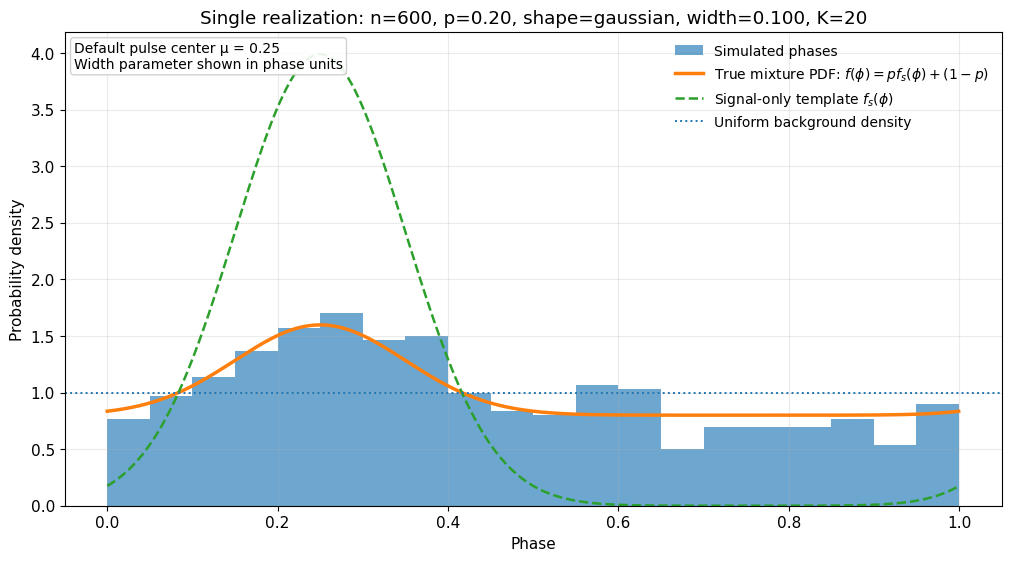

Single-realization results
        $\chi^2$ : statistic =      70.8667,   p-value =  6.59742e-08,   -log10(p) =    7.181
              KS : statistic =     0.125976,   p-value =  9.27511e-09,   -log10(p) =    8.033
          Kuiper : statistic =     0.143483,   p-value =  1.31161e-09,   -log10(p) =    8.882
     Beran-Gauss : statistic =      57.2021,   p-value =  3.93254e-14,   -log10(p) =   13.405
Rayleigh $Z_1^2$ : statistic =      51.1738,   p-value =  7.72242e-12,   -log10(p) =   11.112
          H-test : statistic =       54.402,   p-value =  3.95062e-10,   -log10(p) =    9.403


In [7]:

rng = np.random.default_rng(cfg.seed)
phases = sample_phases(rng, cfg)
results = compute_all_tests(phases, cfg)

plot_single_realization(phases, cfg)

print("Single-realization results")
print("=" * 78)
for name, (stat, pval) in results.items():
    sig = robust_significance_from_p(np.array([pval]))[0]
    print(f"{name:>16s} : statistic = {stat:12.6g},   p-value = {pval:12.6g},   -log10(p) = {sig:8.3f}")


## 2) Sensitivity versus pulsed fraction

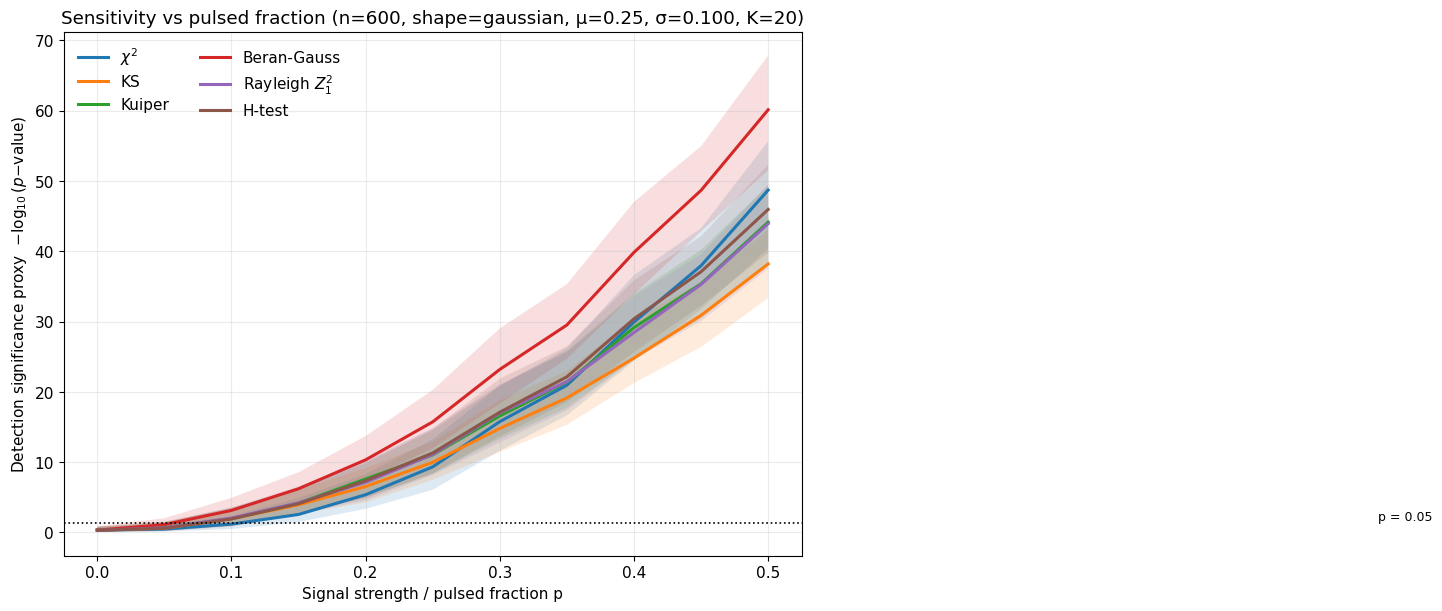

In [8]:

rng = np.random.default_rng(cfg.seed)
summary = sensitivity_vs_amplitude(cfg, p_grid, n_trials_1d, rng)
plot_sensitivity_vs_amplitude(summary, p_grid, cfg)


## 3) Width-vs-amplitude heat maps

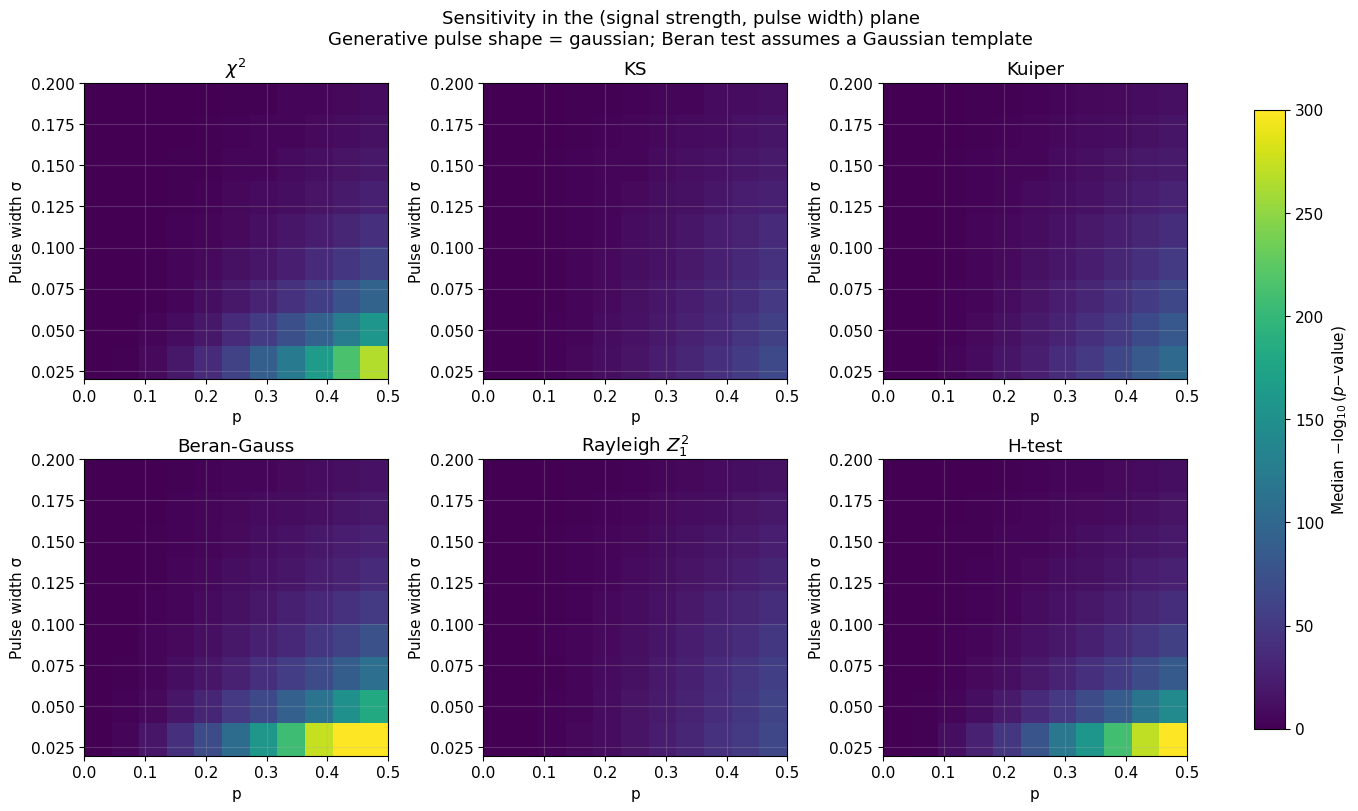

In [9]:

rng = np.random.default_rng(cfg.seed)
heatmaps = sensitivity_grid(cfg, p_grid, sigma_grid, n_trials_2d, rng)
plot_width_amplitude_heatmaps(heatmaps, p_grid, sigma_grid, cfg)


## 4) Dependence of the chi-square test on the number of bins

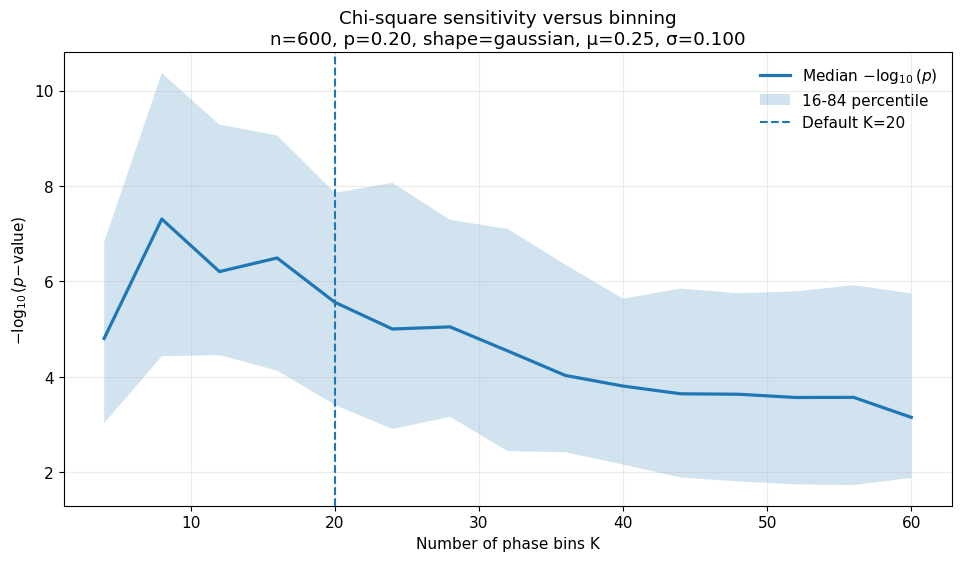

In [10]:

rng = np.random.default_rng(cfg.seed)
ks, med, bounds = chi_square_bin_study(cfg, k_grid, n_trials_1d, rng)
plot_chi_square_bin_dependence(ks, med, bounds, cfg)



## Optional ideas to explore

Try changing one thing at a time in the **User controls** cell and rerun the notebook:

1. Increase or decrease `cfg.p` to see how quickly each test responds.
2. Change `cfg.sigma` to compare narrow pulses with broad pulses.
3. Switch `cfg.pulse_shape` from `"gaussian"` to `"top_hat"` or `"two_peak"` and see which tests become more or less effective.
4. Increase `cfg.n_events` to examine sample-size scaling.
5. Change `cfg.k_bins` and compare the histogram and the $\chi^2$ performance.
6. Increase `cfg.h_mmax` when using non-sinusoidal or multi-peak profiles.

### Expected qualitative behavior

- **Chi-square** can be strongly affected by the number of bins.
- **KS** is generic, but may not be the most sensitive for narrow localized pulses.
- **Kuiper** is often preferable to KS on circular phase data.
- **Beran-Gauss** should do especially well when the true signal is close to the assumed Gaussian template.
- **Rayleigh $Z_1^2$** is most naturally tuned to a single-harmonic sinusoidal modulation.
- **H-test** usually adapts better than Rayleigh when multiple harmonics matter.
